In [2]:
import pandas as pd
import numpy as np

In [3]:
# Data 불러오기

fruits = pd.read_csv("../Data/fruits.csv")

fruits.head()

,length,weight,name
0,25.4,242.0,apple
1,26.3,290.0,apple
2,26.5,340.0,apple
3,29.0,363.0,apple
4,29.0,430.0,apple


In [4]:
# 데이터 구성 확인
fruits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   length  49 non-null     float64
 1   weight  49 non-null     float64
 2   name    49 non-null     object 
dtypes: float64(2), object(1)
memory usage: 1.3+ KB


In [6]:
# 사과만 불러오기
apple = fruits.loc[:34,:]
apple.tail()

,length,weight,name
30,38.5,920.0,apple
31,38.5,955.0,apple
32,39.5,925.0,apple
33,41.0,975.0,apple
34,41.0,950.0,apple


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import warnings
warnings.filterwarnings('ignore')

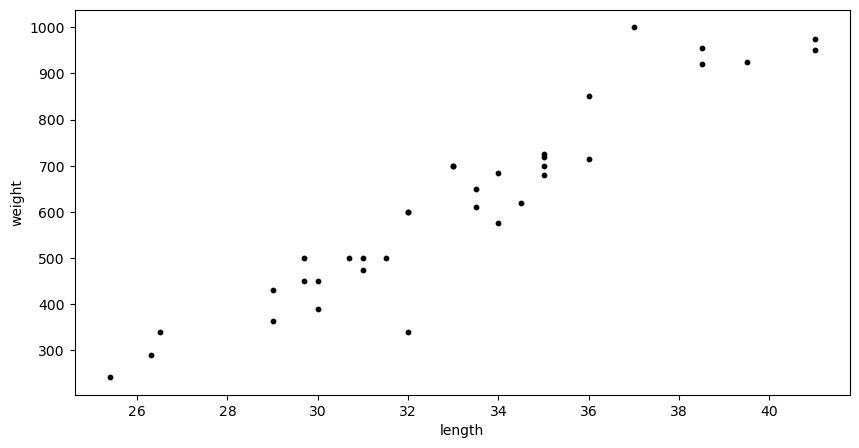

In [ ]:
# apple의 산포도 확인

plt.style.use('default')

apple.plot(
  kind='scatter',
  x='length',
  y='weight',
  c='black',
  s=10,
  figsize=(10,5)
)

plt.show()

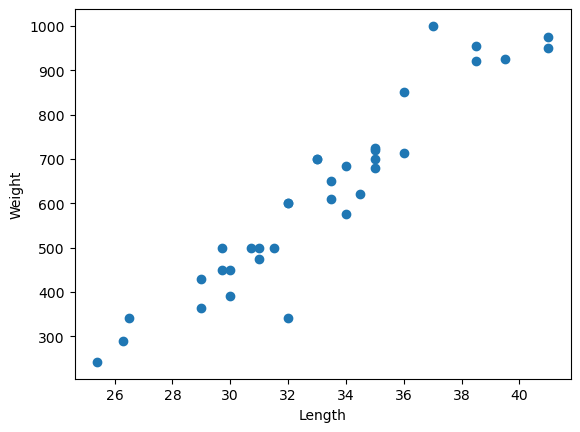

In [20]:
plt.scatter(
  apple['length'],
  apple['weight'],
),

plt.xlabel('Length')
plt.ylabel('Weight')

plt.show()

In [12]:
# 딸기
berry = fruits[35:]
fruits.head()

,length,weight,name
0,25.4,242.0,apple
1,26.3,290.0,apple
2,26.5,340.0,apple
3,29.0,363.0,apple
4,29.0,430.0,apple


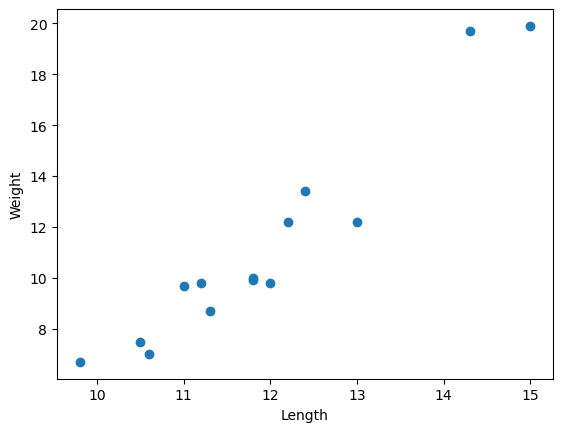

In [21]:
plt.scatter(
  berry['length'],
  berry['weight'],
),

plt.xlabel('Length')
plt.ylabel('Weight')

plt.show()

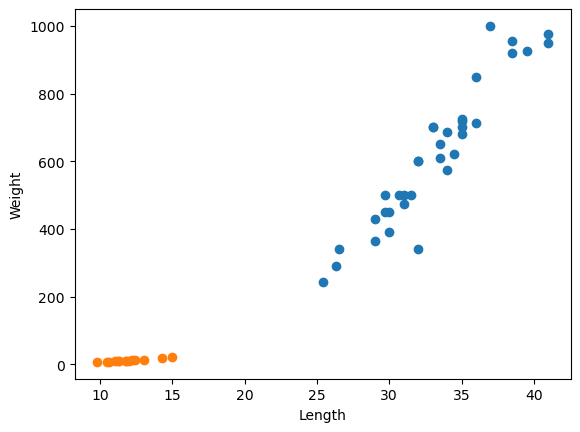

In [19]:
# 2개의 Dataset의 산포도를 한꺼번에 비교하여 그리기
plt.scatter(
  apple['length'],
  apple['weight'],
)


plt.scatter(
  berry['length'],
  berry['weight'],
)

plt.xlabel('Length')
plt.ylabel('Weight')

plt.show()

---
#### 머신러닝을 위한 데이터 준비
: Feature와 Target 분리

In [23]:
fruits.head()

,length,weight,name
0,25.4,242.0,apple
1,26.3,290.0,apple
2,26.5,340.0,apple
3,29.0,363.0,apple
4,29.0,430.0,apple


In [22]:
# Feature Data
fruitsData = fruits[['length','weight']]
fruitsData.head()

,length,weight
0,25.4,242.0
1,26.3,290.0
2,26.5,340.0
3,29.0,363.0
4,29.0,430.0


In [24]:
# Target Data
fruitsTarget = fruits['name']

fruitsTarget.head()

0    apple
1    apple
2    apple
3    apple
4    apple
Name: name, dtype: object

### KNN(k-Nearest Neigbors)

In [25]:
from sklearn.neighbors import KNeighborsClassifier

In [26]:
kn = KNeighborsClassifier() # n_neighbors = 5가 default

In [27]:
# 학습시키기
kn.fit(fruitsData, fruitsTarget)

KNeighborsClassifier()

In [28]:
# 정확도
kn.score(fruitsData, fruitsTarget)

1.0

In [29]:
pred = kn.predict(fruitsData)
pred

array(['apple', 'apple', 'apple', 'apple', 'apple', 'apple', 'apple',
       'apple', 'apple', 'apple', 'apple', 'apple', 'apple', 'apple',
       'apple', 'apple', 'apple', 'apple', 'apple', 'apple', 'apple',
       'apple', 'apple', 'apple', 'apple', 'apple', 'apple', 'apple',
       'apple', 'apple', 'apple', 'apple', 'apple', 'apple', 'apple',
       'berry', 'berry', 'berry', 'berry', 'berry', 'berry', 'berry',
       'berry', 'berry', 'berry', 'berry', 'berry', 'berry', 'berry'],
      dtype=object)

In [31]:
(pred == fruitsTarget).mean()

1.0

### 예측해보기
길이가 30cm이고 무게가 600g인것은 ? (apple, berry)

In [33]:
test = pd.DataFrame(
  {
    'length' : [30],
    'weight' : [600]
  }
)

test

,length,weight
0,30,600


In [35]:
kn.predict(test)[0]

'apple'

#### 산포도로 에측 범위 확인하기

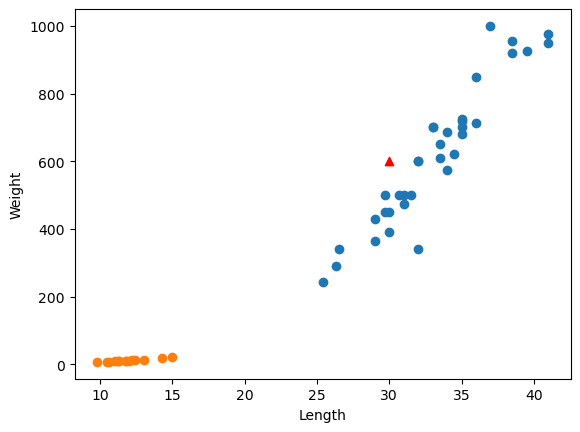

In [38]:
# 2개의 Dataset의 산포도를 한꺼번에 비교하여 그리기
plt.scatter(
  apple['length'],
  apple['weight'],
)


plt.scatter(
  berry['length'],
  berry['weight'],
)

plt.scatter(
  test['length'],
  test['weight'],
  marker="^",
  c='red'
)

plt.xlabel('Length')
plt.ylabel('Weight')

plt.show()